In [ ]:
!nvidia-smi

Sat Mar  7 18:24:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install ultralytics ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.4 MB/s eta 0:00:00


In [ ]:
import os
import torch
import numpy as np
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
DATA_CONFIG = 'african-wildlife.yaml'

In [ ]:
print("--- Training YOLOv8 (5 Epochs) ---")
model_v8 = YOLO('yolov8n.pt')
model_v8.train(data=DATA_CONFIG, epochs=5, imgsz=320, fraction=0.1, device=0)

--- Training YOLOv8 (5 Epochs) ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8c78571ac0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
print("\n--- Training YOLOv5 (5 Epochs) ---")
model_v5 = YOLO('yolov5s.pt')
model_v5.train(data=DATA_CONFIG, epochs=5, imgsz=320, fraction=0.1, device=0)


--- Training YOLOv5 (5 Epochs) ---
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8c223def90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
# 3. ENSEMBLE LOGIC (Weighted Boxes Fusion)
def ensemble_inference(img_path):
    # Get raw predictions
    res_v8 = model_v8(img_path)[0]
    res_v5 = model_v5(img_path)[0]

    # Format boxes for ensembling (Normalized 0-1)
    # ensemble-boxes expects: [x1, y1, x2, y2]
    boxes_list = [
        res_v8.boxes.xyxyn.cpu().numpy().tolist(),
        res_v5.boxes.xyxyn.cpu().numpy().tolist()
    ]
    scores_list = [
        res_v8.boxes.conf.cpu().numpy().tolist(),
        res_v5.boxes.conf.cpu().numpy().tolist()
    ]
    labels_list = [
        res_v8.boxes.cls.cpu().numpy().astype(int).tolist(),
        res_v5.boxes.cls.cpu().numpy().astype(int).tolist()
    ]

    # Perform Weighted Boxes Fusion
    # iou_thr: overlap threshold, skip_box_thr: confidence filter
    boxes, scores, labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights=[2, 1], iou_thr=0.5, skip_box_thr=0.4
    )

    print(f"Ensemble identified {len(boxes)} refined objects.")
    return boxes, scores, labels

In [ ]:
#Execution
test_img = "/content/1 (40).jpg" # Replace with local wildlife image path
ens_boxes, ens_scores, ens_labels = ensemble_inference(test_img)


image 1/1 /content/1 (40).jpg: 288x320 (no detections), 42.7ms
Speed: 1.0ms preprocess, 42.7ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 320)

image 1/1 /content/1 (40).jpg: 288x320 5 buffalos, 1 elephant, 31.7ms
Speed: 0.8ms preprocess, 31.7ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 320)
Ensemble identified 5 refined objects.


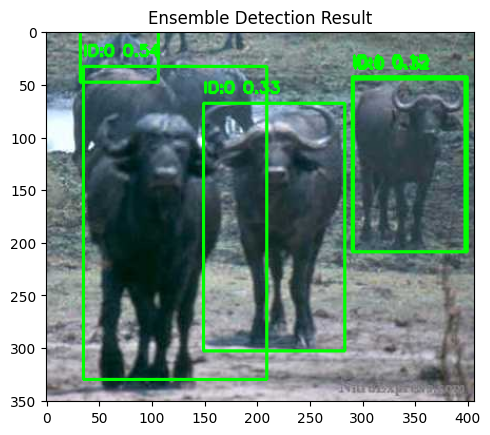

In [ ]:
import cv2
import matplotlib.pyplot as plt

# After running ensemble_inference, we plot the boxes manually to show the "Refined" output
img = cv2.imread('/content/1 (40).jpg')
for box, score, label in zip(ens_boxes, ens_scores, ens_labels):
    x1, y1, x2, y2 = box
    # Convert normalized to pixel coordinates
    ih, iw, _ = img.shape
    cv2.rectangle(img, (int(x1*iw), int(y1*ih)), (int(x2*iw), int(y2*ih)), (0, 255, 0), 2)
    cv2.putText(img, f'ID:{int(label)} {score:.2f}', (int(x1*iw), int(y1*ih)-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ensemble Detection Result")
plt.show()